In [6]:
#script to plot MZR plots across cosmic time
import os
import numpy as np
import h5py
import time
import cmasher as cm
import string
from pylab import genfromtxt
from pathlib import Path
import unyt
import pandas as pd

import scipy.integrate as integrate
from scipy.optimize import curve_fit, root_scalar
from scipy.stats import gaussian_kde

import astropy.constants as cons
from astropy.cosmology import FlatLambdaCDM
from astropy import units as u
from astropy.io import fits

import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import LogNorm, LinearSegmentedColormap
import matplotlib.ticker as mtickerbrms
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as colors
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


COLIBRE_COLORS = [
    ('m5', '#C4E8FF'),
    ('m6', '#FF9F6E'),
    ('m7', '#D12424'),
]
PATH_EFFECTS = [pe.Stroke(linewidth=5, foreground="k"), pe.Normal()]
LINE_WIDTH = 3.5

defcolcycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

cosmo = FlatLambdaCDM(H0=68.1, Om0=0.306) #same parameters as Chaikin+25b (adopted by COLIBRE from Abbott et al. 2022)
masslimit_m5 = 2.3e5
masslimit_m6 = 1.84e6
masslimit_m7 = 1.47e7

masslimits = {"m5": masslimit_m5, "m6": masslimit_m6, "m7": masslimit_m7}
bbox = dict(boxstyle='round,pad=0.4',facecolor='white',edgecolor='black',alpha=0.9)

#path to store data of interest
#mypath = '/cosma8/data/do019/dc-shar7/mydata/'
#colibre runs stored at
#path = '/cosma8/data/dp004/colibre/Runs/'
#path to my home
#homepath = '/cosma/home/do019/dc-shar7/'
#path to EAGLE data
#eaglepath = '/snap8/scratch/dp004/dc-mcgi1/EAGLE/'
#path to TNG data
#tngpath = '/snap8/scratch/dp004/dc-mcgi1/TNG/'

simpath = 'simulated_data/'

Finished in 0.17 s


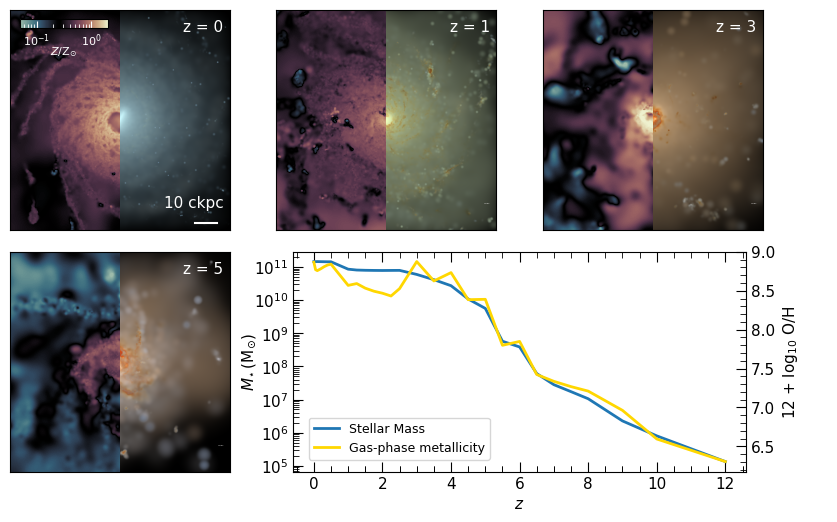

In [8]:
#Figure 1 of Sharda et al. 2026
_tstart = time.time()

f = plt.figure(figsize=(10, 6), constrained_layout=False)
gs = f.add_gridspec(2, 3, wspace=0.1, hspace=0.1, height_ratios=[1.00, 1.])
ax = np.empty((2, 3), dtype=object)
ax[0,0] = f.add_subplot(gs[0,0])
ax[0,1] = f.add_subplot(gs[0,1])
ax[0,2] = f.add_subplot(gs[0,2])
ax[1,0] = f.add_subplot(gs[1,0])
ax[1,1] = f.add_subplot(gs[1,1:3])

# remove the original wide axis
ax[1,1].remove()
# create a smaller one in the same grid cell
parent = f.add_subplot(gs[1,1:3])
ax[1,1] = inset_axes(parent, width="89%", height="100%", loc='center')
# optionally turn off the parent axis
parent.set_axis_off()


fontsize = 11

snaps = ['0127', '0092', '0064', '0048']
zz = [0, 1, 3, 5]
track_id = 918

lw = 2
lower, upper = 0.1, 1
n_colors = 100
new_colors = cm.copper_s_r(np.linspace(lower, upper, n_colors))
cmap_z = LinearSegmentedColormap.from_list('cropped_copper_s_r', new_colors)

vmin_z, vmax_z = 0.05, 2
vmin_m, vmax_m = 1e-2, 1e5
obsv = 'jwst'
for idx, snap in enumerate(snaps):

    i, j = divmod(idx, 3)

    # ---------------- METALLICITY ----------------
    bb = np.load(simpath+
                 f'projection_metallicity_{snap}_excl_50kpc_comoving_trackId_{str(track_id).zfill(8)}.npy').T

    im_z = ax[i, j].imshow(bb[:, 0:250] / 0.0134, origin='lower', norm=LogNorm(vmin=vmin_z, vmax=vmax_z), cmap=cmap_z,
                           extent=[0, 250, 0, 500])

    cc = np.load(simpath+
                 f'partridge_50kpc_comoving_snap_{snap}_trackID_{str(track_id).zfill(3)}_{obsv}.npy')

    im_m = ax[i, j].imshow(cc[:, 250:], extent=[250, 500, 0, 500])

    ax[i,j].set_xticks([])
    ax[i,j].set_yticks([])
    ax[i, j].text(0.97, 0.92, f'z = {zz[idx]}', ha='right', va='center', fontsize=fontsize, 
                  transform=ax[i, j].transAxes, color='white')
    ax[i, j].set_xticklabels([])
    ax[i, j].set_yticklabels([])

    if i==0 and j==0:
        ax[i, j].plot([420, 420+51.2], [15, 15], c='white')
        ax[i, j].text(0.97, 0.12, '10 ckpc', ha='right', va='center', fontsize=fontsize, 
                      transform=ax[i, j].transAxes, color='white')
    else:
        ax[i, j].plot([420, 420+51.2], [15, 15], c='k', ls='None')
        ax[i, j].text(0.97, 0.12, '10 ckpc', ha='right', va='center', fontsize=0, 
                      transform=ax[i, j].transAxes, color='white')

bb=pd.read_csv(simpath+'colibre_l025m5_trackID_918_fig1.csv')

ax[1,1].plot(bb['z'], bb['Mstar'], label='Stellar Mass',lw=2)
ax2 = ax[1,1].twinx()
ax2.plot(bb['z'], bb['12+log(O/H)'], c='gold',label='Gas-phase metallicity',lw=2)
ax[1,1].set_yscale('log')
ax[1,1].legend(loc='lower left',fontsize=fontsize-2,bbox_to_anchor=(0.02,0.025))
ax[1,1].set_xlabel(r'$z$', fontsize=fontsize)
ax[1,1].set_ylabel(r'$M_{\star}\,(\rm{M_{\odot}})$', fontsize=fontsize,labelpad=-3)
ax2.set_ylabel(r'12 + $\log_{10}\,\rm{O/H}$', fontsize=fontsize)

cax = f.add_axes([ax[0,0].get_position().x0 + 0.01,
                  ax[0,0].get_position().y1 - 0.03,
                  ax[0,0].get_position().width * 0.4,
                  0.015])

cb = plt.colorbar(im_z, cax=cax, orientation='horizontal')
cb.set_label(r'$Z/\rm{Z_{\odot}}$', fontsize=8, color='white',labelpad=-3)
cb.ax.tick_params(which='major',direction='in',labelsize=8,length=5,colors='white')
cb.ax.tick_params(which='minor',direction='in',labelsize=8,length=3,color='white')

color='k'
ax[1,1].tick_params(axis='both', which='major', direction = 'in', top=True, right=False, labelsize=fontsize, length=7, color=color)
ax[1,1].minorticks_on()
ax[1,1].tick_params(axis='both', which='minor', direction = 'in', top=True, right=False, labelsize=fontsize, length=4, color=color)

ax2.tick_params(axis='both', which='major', direction = 'in', top=False, right=True, left=False, labelsize=fontsize, length=7, color=color)
ax2.minorticks_on()
ax2.tick_params(axis='both', which='minor', direction = 'in', top=False, right=True, left=False, labelsize=fontsize, length=4, color=color)

print(f"Finished in {time.time() - _tstart:.2f} s")
#f.savefig('Figure1.png', bbox_inches='tight', dpi=300)
